In [121]:
import os
import re
import string
from gensim.models import Word2Vec
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /home/guilherme/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/guilherme/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [122]:
import spacy

nlp = spacy.load("pt_core_news_sm")

# def lematizar_texto(tokens):
#     doc = nlp(" ".join(tokens))
#     return [token.lemma_ for token in doc]

def spacy_text(text):
    doc = nlp(text)

    tokens = []

    for token in doc:
        if not token.is_stop and len(token.text) > 2:
            tokens.append(token.lemma_)
    return tokens

In [123]:
def limpar_e_preparar_dados(caminhos_ficheiros):
    """
    Lê os ficheiros, remove pontuação, converte para minúsculas 
    e tokeniza em frases/palavras.
    """
    sentencas_processadas = []
    #stop_words = set(stopwords.words('portuguese'))

    translator = str.maketrans('', '', string.punctuation)
    
    for caminho in caminhos_ficheiros:
        try:    
            print(f"A processar: {caminho}...")
            with open(caminho, 'r', encoding='utf-8') as f:
                for linha in f:
                    # 1. Limpeza básica e remoção de números/pontuação
                    linha = linha.strip().lower()
                    linha = re.sub(r"\d+", "", linha)
                    linha = linha.translate(translator)
                    
                    tokens = spacy_text(linha)
                    if tokens:
                        sentencas_processadas.append(tokens)
                     

                    # 2. Tokenização (dividir em palavras)
                    # tokens = word_tokenize(linha)

                    # 3. Eliminar StopWords
                    # stopWRemove = [w for w in tokens if w not in stop_words and len(w) > 2]

                    # 4. Lemmatize
                    #if stopWRemove:
                        #final_clean_text = lematizar_texto(stopWRemove)                    
                        #sentencas_processadas.append(final_clean_text)
                        
        except FileNotFoundError:
            print(f"Erro: O ficheiro {caminho} não foi encontardo.")
        except Exception as e:
            print(f"Aviso: Ocorreu um erro: {e}"+
                  f"\nO ficheiro {caminho} não foi encontrado.")
        

    return sentencas_processadas

In [124]:
meus_ficheiros = ['livros/Harry Potter e A Pedra Filosofal.txt', 'livros/Harry_Potter_Camara_Secreta-br.txt'
                  , 'livros/harry_potter_e_o_calice_de_fogo-J._K._Rowling.txt','livros/harry_potter_e_o_enigma_do_principe-J._K._Rowling.txt',
                  'livros/J.K.Rowling-5-Harry_Potter_e_a_Ordem_da_Fenix.txt', 'livros/J.K.Rowling-7-Harry_Potter_e_As_Reliquias_da_Morte.txt'] 

dados_treino = limpar_e_preparar_dados(meus_ficheiros)
print(len(dados_treino))
if not dados_treino:
    print("Erro: Não foram encontrados dados para treinar o modelo.")
else:
    print(f"Treinando modelo com {len(dados_treino)} frases...")

    model = Word2Vec(
        sentences=dados_treino,
        vector_size=100,
        epochs=5, 
        window=5, 
        min_count=2, 
        workers=3,
        sg=0
    )

    model_name = "models/my_model_word2vec.model"
    model.save(model_name)

A processar: livros/Harry Potter e A Pedra Filosofal.txt...
A processar: livros/Harry_Potter_Camara_Secreta-br.txt...
A processar: livros/harry_potter_e_o_calice_de_fogo-J._K._Rowling.txt...
A processar: livros/harry_potter_e_o_enigma_do_principe-J._K._Rowling.txt...
A processar: livros/J.K.Rowling-5-Harry_Potter_e_a_Ordem_da_Fenix.txt...
A processar: livros/J.K.Rowling-7-Harry_Potter_e_As_Reliquias_da_Morte.txt...
62890
Treinando modelo com 62890 frases...




_________________Welcome to Harry Potter Books analysis__________________


_____________________1ª Fase - Teste de Similaridade_____________________

Teste de similaridade da palavra 'harry'
Harry : Token: hagrid -> 0.9360
Harry : Token: hermione -> 0.9357
Harry : Token: rony -> 0.9162
Harry : Token: moody -> 0.9021
Harry : Token: ron -> 0.8956


Teste de similaridade da palavra 'vassoura'
Vassoura : Token: pomo -> 0.9963
Vassoura : Token: cuidadosamente -> 0.9955
Vassoura : Token: curvar -> 0.9953
Vassoura : Token: enfiar -> 0.9953
Vassoura : Token: fogo -> 0.9953


Teste de similaridade da palavra 'feitiço'
Feitiço : Token: uso -> 0.9919
Feitiço : Token: defensivo -> 0.9890
Feitiço : Token: artefato -> 0.9886
Feitiço : Token: idade -> 0.9867
Feitiço : Token: comunidade -> 0.9861




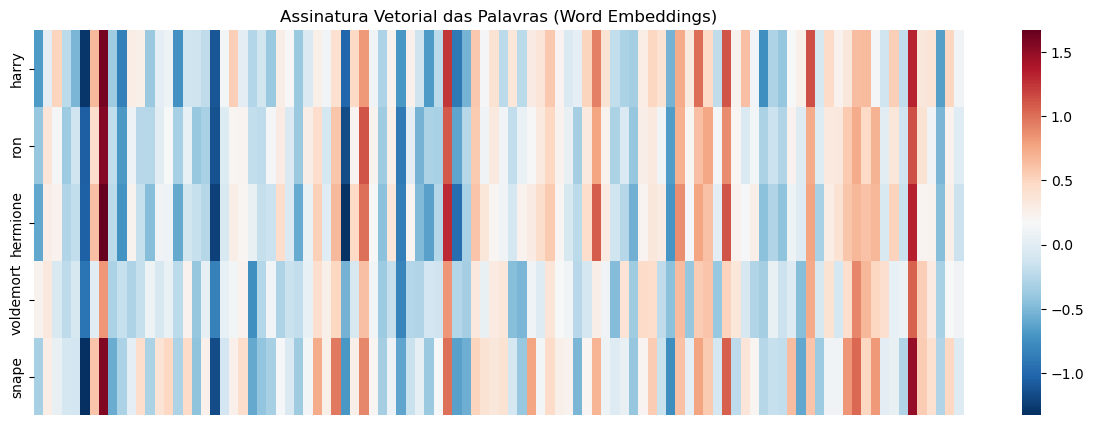

In [151]:
from gensim.models import Word2Vec

print("\n\n_________________Welcome to Harry Potter Books analysis__________________\n\n")

def analysis(model, words):
    print("_____________________1ª Fase - Teste de Similaridade_____________________\n")
    
    for word in words:
        print(f"Teste de similaridade da palavra '{word}'")
        try:
            for token, score in model.wv.most_similar(word, topn=5):
                print(f"{word.capitalize()} : Token: {token} -> {score:.4f}")
        except KeyError as e:
            print(f"Error: {e} -> A palavra {word} não foi encontrada")
        print("\n")

words = ['harry', 'vassoura', 'feitiço']
analysis(model, words)

import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

def plot_vetores_estilo_heatmap(model, lista_palavras):
    # Extrair os vetores do modelo
    dados_vetores = [model.wv[p] for p in lista_palavras]
    
    # Criar um DataFrame para o Seaborn
    df = pd.DataFrame(dados_vetores, index=lista_palavras)
    
    plt.figure(figsize=(15, 5))
    # Usamos o mapa de cores 'RdBu_r' (Red-Blue) para parecer com o teu exemplo
    sns.heatmap(df, cmap='RdBu_r', cbar=True, yticklabels=True, xticklabels=False)
    
    plt.title("Assinatura Vetorial das Palavras (Word Embeddings)")
    plt.show()

# Exemplo de uso:
plot_vetores_estilo_heatmap(model, ['harry', 'ron', 'hermione', 'voldemort', 'snape'])

In [ ]:
print("_____________________2ª Fase - Teste da Analogia_____________________\n")

def Analogies(model, a,b,c):
    try:
        print(model.wv.most_similar(positive=[b,c], negative=[a], topn=30))
    except KeyError as e:
        print(f"Error: {e} -> Uma ou mais das palavras selecionadas não foram encontradas.")

Analogies(model, 'dumbledore', 'bom', 'voldemort')

_____________________2ª Fase - Teste da Analogia_____________________

[('semana', 0.9520489573478699), ('trabalhar', 0.9514023065567017), ('único', 0.9410967826843262), ('tramar', 0.9400733709335327), ('feriado', 0.9384490251541138), ('encontrar', 0.9380310773849487), ('ter', 0.9368807673454285), ('quadribol', 0.935300886631012), ('escolher', 0.9345928430557251), ('vida', 0.9339398741722107), ('aprenderar', 0.9334738850593567), ('aventurar', 0.9331201314926147), ('grimmauld', 0.9323086738586426), ('último', 0.9315460920333862), ('dezessete', 0.9315336346626282), ('descobrir', 0.9314407110214233), ('temer', 0.9311999082565308), ('natal', 0.9304201006889343), ('atacar', 0.9302977919578552), ('permissã£o', 0.9302187561988831), ('hogwart', 0.9301514029502869), ('levamo', 0.9301432371139526), ('anterior', 0.9293991923332214), ('confio', 0.9293676614761353), ('provavelmente', 0.9293171763420105), ('sextafeira', 0.9290028810501099), ('suplementar', 0.9280419945716858), ('lição', 0.9276897311